X2        0
X3        0
X4        0
X5        0
X6        0
X7        0
X8        0
X11.1     0
X11.2     0
X14.8     0
X14.9     0
X14.10    0
X17.4     0
X17.5     0
X17.6     0
X18.1     0
X18.2     0
X18.3     0
X18.4     0
X18.5     0
X18.6     0
X18.7     0
X19.1     0
X19.2     0
X19.3     0
X20.1     0
X20.2     0
X20.3     0
X21       0
X22.1     0
X22.2     0
X22.3     0
X22.4     0
X22.5     0
X22.6     0
X24       0
X25       0
dtype: int64
X2         int64
X3        object
X4         int64
X5         int64
X6         int64
X7         int64
X8         int64
X11.1      int64
X11.2      int64
X14.8      int64
X14.9      int64
X14.10     int64
X17.4      int64
X17.5      int64
X17.6      int64
X18.1      int64
X18.2      int64
X18.3      int64
X18.4      int64
X18.5      int64
X18.6      int64
X18.7      int64
X19.1      int64
X19.2      int64
X19.3      int64
X20.1      int64
X20.2      int64
X20.3      int64
X21        int64
X22.1      int64
X22.2      int64
X22.3      int64

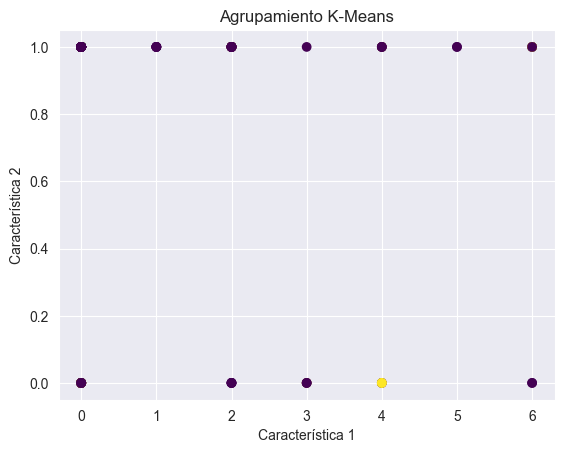

In [7]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Cargar el dataset
data = pd.read_csv('data/previous_data_2.csv')

# Verificar si hay valores nulos
print(data.isnull().sum())

# Opcional: eliminar filas con valores faltantes o convertir valores faltantes a 0
data_clean = data.dropna()  # Eliminar filas con valores nulos
# Alternativa: rellenar con 0 (o con la media, mediana, etc.)
# data_clean = data.fillna(0)

# Verificar si hay columnas no numéricas
print(data_clean.dtypes)
3
# Convertir columnas no numéricas a valores numéricos si es posible (por ejemplo, categorías)
# data_clean['columna'] = pd.to_numeric(data_clean['columna'], errors='coerce')

# Si hay columnas categóricas (no numéricas), puedes eliminarlas o convertirlas
data_clean = data_clean.select_dtypes(include=[float, int])

# Asegurarte de que solo estás pasando datos numéricos a K-Means
X = data_clean.iloc[:, :]

# Definir el número de clusters
k = 2  # Ajusta el número de clusters según el caso

# Crear el modelo K-Means
kmeans = KMeans(n_clusters=k, random_state=42)

# Entrenar el modelo
kmeans.fit(X)

# Predecir los clusters
clusters = kmeans.predict(X)

# Agregar la columna con los clusters predichos al dataframe original
data_clean['Cluster'] = clusters

# Mostrar los centroides de los clusters
print("Centroides de los clusters:")
print(kmeans.cluster_centers_)

# Visualizar los resultados (asumiendo que se puedan proyectar en 2D)
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=clusters, cmap='viridis')
plt.title('Agrupamiento K-Means')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()